In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [3]:
df=pd.read_csv("/content/app_user_behavior_dataset.csv")
df.head()

,user_id,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,...,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source
0,100000,56,Female,India,iOS,2.1,5,3.41,52.71,13,...,20,Basic,9,5,2,NaN,0.31,55.79,1152,Referral
1,100001,46,Male,UK,iOS,1.0,8,24.44,42.03,7,...,7,Free,8,3,3,3.0,0.87,82.39,1059,Email Campaign
2,100002,32,Female,UK,iOS,1.2,12,5.34,76.69,7,...,33,Free,11,6,1,2.0,0.63,42.49,678,Google Ads
3,100003,25,Male,India,Android,2.0,5,3.98,65.38,16,...,17,Basic,6,3,1,3.0,0.43,62.81,92,Organic
4,100004,38,Male,Australia,Android,1.0,10,12.85,57.06,13,...,21,Basic,4,4,2,5.0,0.43,38.21,772,Email Campaign


In [4]:
df.isnull()

,user_id,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,...,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
49996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
49997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
49998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [17]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
device_type,0
app_version,0
sessions_per_week,0
avg_session_duration_min,0
daily_active_minutes,0
feature_clicks_per_session,0


In [19]:
df['rating_given'].value_counts()

,count
rating_given,
4.0,22487
3.0,11199
5.0,9911
2.0,3885
1.0,2518


In [20]:
df.duplicated().sum()


np.int64(0)

In [21]:
df['user_id'].duplicated().sum()

np.int64(0)

In [22]:
df = df.drop_duplicates()

In [23]:
df.shape

(50000, 25)

In [24]:
df['rating_given'] = df['rating_given'].fillna(df['rating_given'].median())

In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,50000.0,124999.500000,14433.901067,100000.00,112499.75,124999.500,137499.25,149999.00
age,50000.0,38.513040,12.094948,18.00,28.00,39.000,49.00,59.00
app_version,50000.0,1.476126,0.470158,1.00,1.10,1.200,2.00,2.10
sessions_per_week,50000.0,7.999680,2.829438,0.00,6.00,8.000,10.00,26.00
avg_session_duration_min,50000.0,13.149842,8.946944,0.06,6.57,11.240,17.57,91.40
daily_active_minutes,50000.0,45.164537,19.505118,5.00,31.65,45.210,58.44,129.13
feature_clicks_per_session,50000.0,12.013920,3.480289,1.00,10.00,12.000,14.00,28.00
notifications_opened_per_week,50000.0,4.996620,2.235180,0.00,3.00,5.000,6.00,16.00
in_app_search_count,50000.0,3.999060,1.997763,0.00,3.00,4.000,5.00,19.00
pages_viewed_per_session,50000.0,13.470760,6.343635,3.00,8.00,13.000,19.00,24.00


In [28]:
for col in ['gender', 'country', 'device_type', 'subscription_type', 'marketing_source']:
    print(col, ":", df[col].unique())

gender : ['Female' 'Male' 'Other']
country : ['India' 'UK' 'Australia' 'Germany' 'Singapore' 'Canada' 'USA']
device_type : ['iOS' 'Android' 'Web']
subscription_type : ['Basic' 'Free' 'Premium']
marketing_source : ['Referral' 'Email Campaign' 'Google Ads' 'Organic' 'Facebook Ads']


In [29]:
features = [
    'sessions_per_week',
    'avg_session_duration_min',
    'daily_active_minutes',
    'feature_clicks_per_session',
    'notifications_opened_per_week',
    'in_app_search_count',
    'pages_viewed_per_session',
    'crash_events_last_30_days',
    'support_tickets_raised',
    'days_since_last_login',
    'ads_clicked_last_30_days',
    'content_downloads',
    'social_shares',
    'churn_risk_score',
    'engagement_score',
    'account_age_days'
]

X = df[features]
X.head()

,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,ads_clicked_last_30_days,content_downloads,social_shares,churn_risk_score,engagement_score,account_age_days
0,5,3.41,52.71,13,5,8,8,1,0,20,9,5,2,0.31,55.79,1152
1,8,24.44,42.03,7,7,3,7,0,0,7,8,3,3,0.87,82.39,1059
2,12,5.34,76.69,7,5,2,21,1,0,33,11,6,1,0.63,42.49,678
3,5,3.98,65.38,16,8,4,13,0,0,17,6,3,1,0.43,62.81,92
4,10,12.85,57.06,13,7,3,15,0,0,21,4,4,2,0.43,38.21,772


In [31]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=features)
X_scaled.head()

,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,ads_clicked_last_30_days,content_downloads,social_shares,churn_risk_score,engagement_score,account_age_days
0,-1.060179,-1.088633,0.386849,0.283336,0.001512,2.002730,-0.862410,0.950305,-0.442514,-0.156968,1.224561,1.153562,-0.001019,-0.661298,-0.616659,1.586435
1,0.000113,1.261914,-0.160705,-1.440677,0.896304,-0.500094,-1.020050,-0.627017,-0.442514,-1.158114,0.816944,-0.001305,0.706485,1.279270,1.175953,1.317310
2,1.413835,-0.872915,1.616282,-1.440677,0.001512,-1.000659,1.186909,0.950305,-0.442514,0.844179,2.039793,1.730996,-0.708522,0.447598,-1.512965,0.214765
3,-1.060179,-1.024924,1.036429,1.145342,1.343700,0.000471,-0.074211,-0.627017,-0.442514,-0.388001,0.001712,-0.001305,-0.708522,-0.245462,-0.143571,-1.481014
4,0.706974,-0.033514,0.609870,0.283336,0.896304,-0.500094,0.241069,-0.627017,-0.442514,-0.079956,-0.813520,0.576129,-0.001019,-0.245462,-1.801401,0.486784


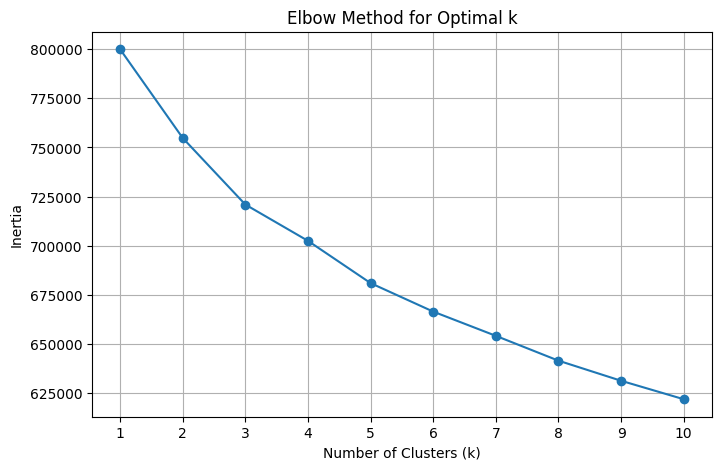

In [33]:

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [34]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

df['cluster'].value_counts()

,count
cluster,
0,17338
3,17020
1,8535
2,7107


In [35]:
profile_cols = features + ['engagement_score', 'churn_risk_score', 'rating_given']

cluster_profile = df.groupby('cluster')[profile_cols].mean().round(2)
cluster_profile

,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,ads_clicked_last_30_days,content_downloads,social_shares,churn_risk_score,engagement_score,account_age_days,engagement_score,churn_risk_score,rating_given
cluster,,,,,,,,,,,,,,,,,,,
0,7.97,10.13,45.26,12.04,4.99,4.02,7.84,0.39,0.00,22.03,6.03,3.01,2.01,0.5,64.88,603.94,64.88,0.5,3.67
1,8.02,12.09,45.08,11.96,5.02,3.99,13.46,0.41,1.11,22.02,6.00,2.99,2.01,0.5,64.94,600.10,64.94,0.5,3.67
2,8.07,29.14,44.82,11.99,4.97,3.98,13.64,0.39,0.05,22.09,5.91,3.06,1.98,0.5,64.95,613.95,64.95,0.5,3.67
3,7.99,10.08,45.25,12.03,5.01,3.99,19.14,0.40,0.00,22.03,6.00,2.98,2.00,0.5,65.00,601.23,65.00,0.5,3.66


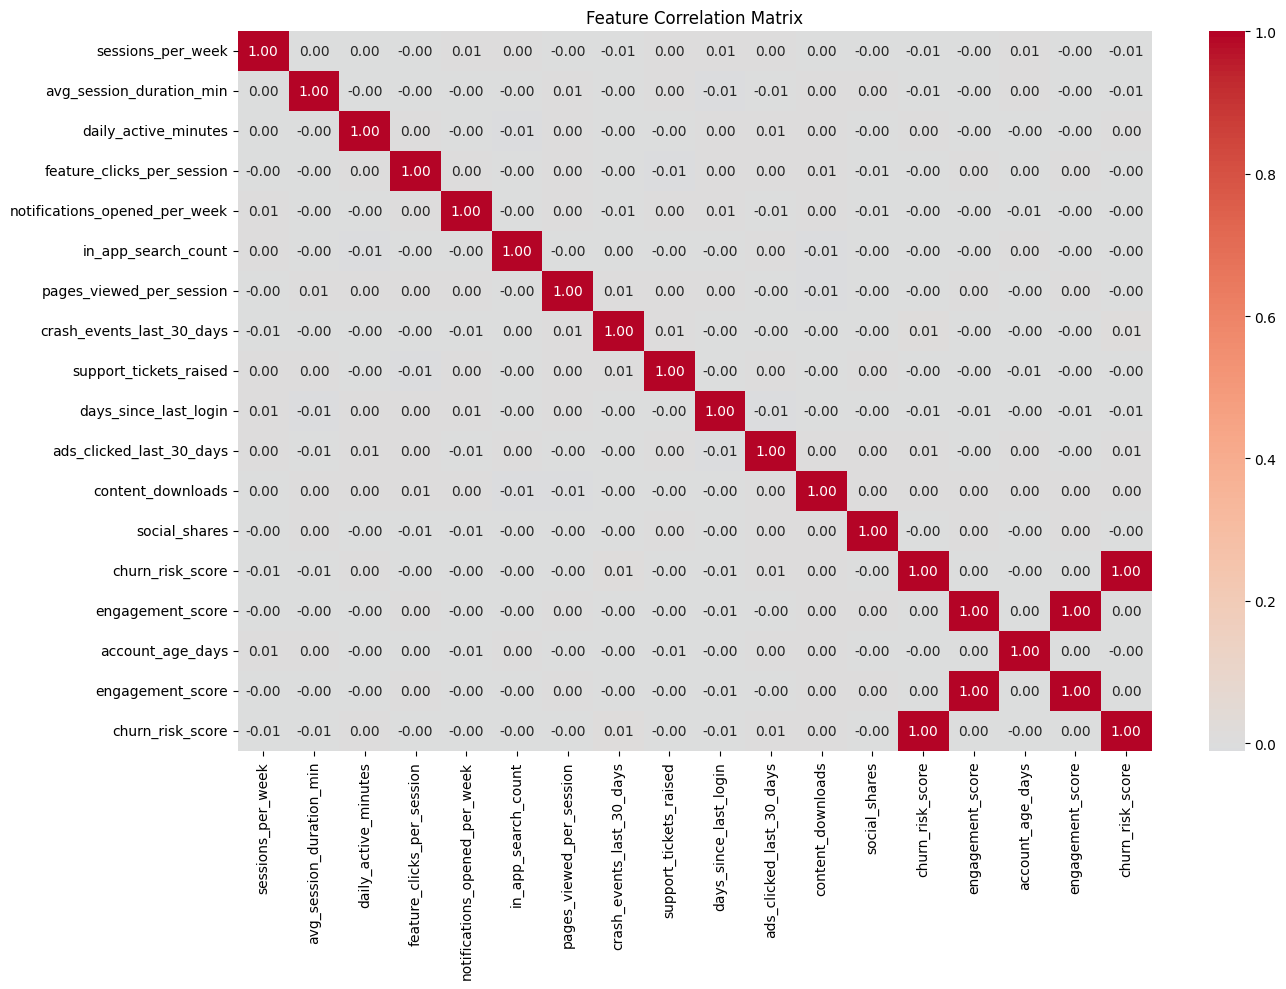

In [38]:

corr_cols = features + ['engagement_score', 'churn_risk_score']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [40]:
cluster_summary = df.groupby('cluster')[['avg_session_duration_min', 'pages_viewed_per_session', 'support_tickets_raised']].mean().round(2)
cluster_summary

,avg_session_duration_min,pages_viewed_per_session,support_tickets_raised
cluster,,,
0,10.13,7.84,0.00
1,12.09,13.46,1.11
2,29.14,13.64,0.05
3,10.08,19.14,0.00


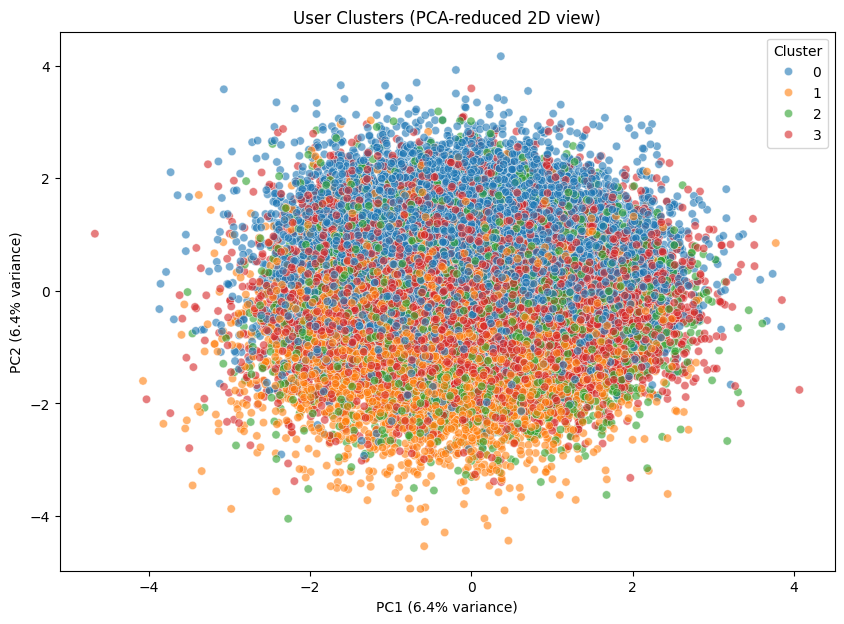

Total variance explained by 2 PCs: 0.12833716703503875


In [41]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='cluster', palette='tab10', alpha=0.6)
plt.title('User Clusters (PCA-reduced 2D view)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.show()

print("Total variance explained by 2 PCs:", pca.explained_variance_ratio_.sum())

In [42]:
sample_idx = df.sample(5000, random_state=42).index
silhouette = silhouette_score(X_scaled.loc[sample_idx], df.loc[sample_idx, 'cluster'])
print("Silhouette Score:", silhouette)

Silhouette Score: 0.04959493586102525


In [44]:

final_profile = df.groupby('cluster').agg({
    'avg_session_duration_min': 'mean',
    'pages_viewed_per_session': 'mean',
    'support_tickets_raised': 'mean',
    'user_id': 'count'
}).round(2).rename(columns={'user_id': 'num_users'})

final_profile

,avg_session_duration_min,pages_viewed_per_session,support_tickets_raised,num_users
cluster,,,,
0,10.13,7.84,0.00,17338
1,12.09,13.46,1.11,8535
2,29.14,13.64,0.05,7107
3,10.08,19.14,0.00,17020


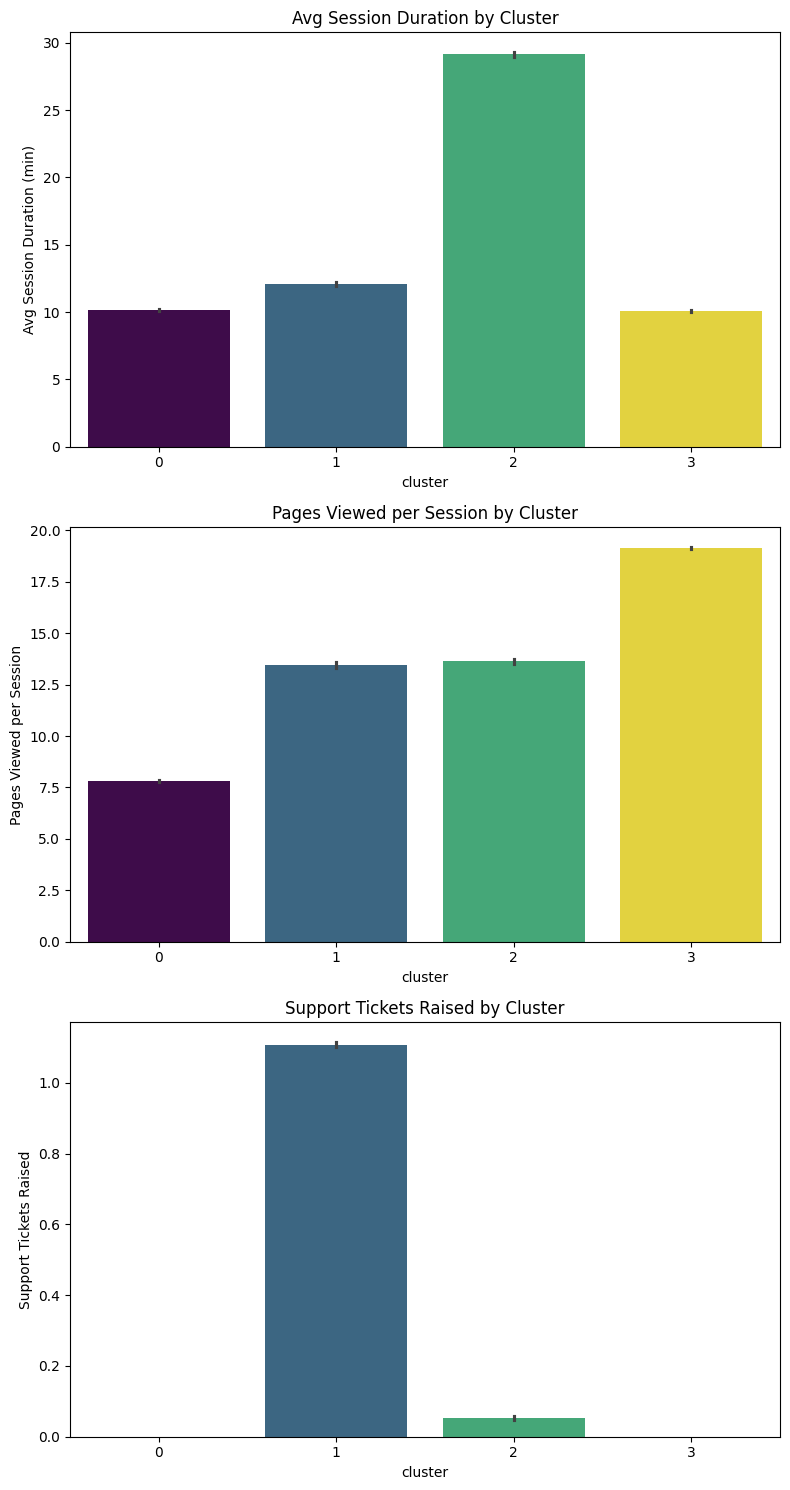

In [48]:
fig, axes = plt.subplots(3, 1, figsize=(8, 15))

sns.barplot(data=df, x='cluster', y='avg_session_duration_min', hue='cluster', ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Avg Session Duration by Cluster')
axes[0].set_ylabel('Avg Session Duration (min)')

sns.barplot(data=df, x='cluster', y='pages_viewed_per_session', hue='cluster', ax=axes[1], palette='viridis', legend=False)
axes[1].set_title('Pages Viewed per Session by Cluster')
axes[1].set_ylabel('Pages Viewed per Session')

sns.barplot(data=df, x='cluster', y='support_tickets_raised', hue='cluster', ax=axes[2], palette='viridis', legend=False)
axes[2].set_title('Support Tickets Raised by Cluster')
axes[2].set_ylabel('Support Tickets Raised')

plt.tight_layout()
plt.show()

In [50]:

cluster_0_users = df[df['cluster'] == 0]['user_id'].tolist()
cluster_1_users = df[df['cluster'] == 1]['user_id'].tolist()
cluster_2_users = df[df['cluster'] == 2]['user_id'].tolist()
cluster_3_users = df[df['cluster'] == 3]['user_id'].tolist()

print("Cluster 0 (Short-session, low-depth):", len(cluster_0_users), "users")
print("Cluster 1 (Higher-support-contact):", len(cluster_1_users), "users")
print("Cluster 2 (Long-session):", len(cluster_2_users), "users")
print("Cluster 3 (High-page-depth):", len(cluster_3_users), "users")


cluster_names = {
    0: 'Short-Session Baseline',
    1: 'Higher-Support-Contact',
    2: 'Long-Session',
    3: 'High-Page-Depth Browser'
}
df['cluster_label'] = df['cluster'].map(cluster_names)

export_cols = ['user_id', 'cluster', 'cluster_label', 'avg_session_duration_min',
               'pages_viewed_per_session', 'support_tickets_raised',
               'engagement_score', 'churn_risk_score']
df[export_cols].to_csv('user_cluster_assignments.csv', index=False)
print("Exported: user_cluster_assignments.csv")

Cluster 0 (Short-session, low-depth): 17338 users
Cluster 1 (Higher-support-contact): 8535 users
Cluster 2 (Long-session): 7107 users
Cluster 3 (High-page-depth): 17020 users
Exported: user_cluster_assignments.csv
